In [ ]:
import re

with open('../data/transcripts_raw/podcasts/pc_1.txt', 'r', encoding='utf-8') as f:
    # Only keep the lines that do NOT match the timestamp format (e.g., 0:06)
    content = [line for line in f if not re.match(r'^\d+:\d+', line)]

# Write the cleaned content to the destination file
with open('../data/transcripts_processed/podcasts/pc_1.txt', 'w', encoding='utf-8') as f:
    f.writelines(content)

print("File processed and saved to ./transcripts_processed/podcasts/pc_1.txt")

In [ ]:
import pandas as pd
import os
import json

# 1. Cấu hình đường dẫn
input_folder = "../data/hsk_vocab_raw/"
output_folder = "../data/hsk_vocab_processed/"

# Tạo thư mục đầu ra nếu chưa tồn tại
os.makedirs(output_folder, exist_ok=True)

def process_meaning(text):
    """
    Tách chuỗi thành mảng các nghĩa.
    Xử lý cả trường hợp nhiều nghĩa trong 1 ô (ngắt dòng bằng Alt+Enter)
    """
    if pd.isna(text):
        return []
    # Thay thế các kiểu ngắt dòng khác nhau và tách thành list
    meanings = str(text).replace('\r', '\n').split('\n')
    # Loại bỏ khoảng trắng thừa và lọc bỏ các chuỗi rỗng
    return [m.strip() for m in meanings if m.strip()]

def clean_stt(value, default_index):
    """Ép STT về số nguyên sạch"""
    if pd.isna(value):
        return default_index
    try:
        return int(float(value))
    except (ValueError, TypeError):
        return str(value).strip()

# 2. Duyệt tất cả file trong thư mục đầu vào
for file_name in os.listdir(input_folder):
    # Chỉ xử lý file Excel và bỏ qua các file tạm của hệ thống
    if file_name.endswith(".xlsx") and not file_name.startswith((".", "~$")):
        file_path = os.path.join(input_folder, file_name)
        
        try:
            # Đọc file không dùng header (vì ta sẽ truy cập theo chỉ số cột 0, 1, 2...)
            df = pd.read_excel(file_path, header=None, engine='openpyxl')
            
            processed_dict = {}
            current_hanzi = None  # Biến lưu vết từ Hán đang xử lý cho các dòng gộp
            
            for index, row in df.iterrows():
                # Giả định cấu trúc cột: 0:STT, 1:Hanzi, 2:Pinyin, 3:Vietnamese, 4:English
                raw_hanzi = str(row[1]).strip() if pd.notna(row[1]) else ""
                
                # TRƯỜNG HỢP A: Có Hanzi mới -> Khởi tạo Object mới trong Dictionary
                if raw_hanzi:
                    current_hanzi = raw_hanzi
                    processed_dict[current_hanzi] = {
                        "id": clean_stt(row[0], index + 1),
                        "pinyin": str(row[2]).strip() if pd.notna(row[2]) else "",
                        "vietnamese": process_meaning(row[3]),
                        "english": process_meaning(row[4])
                    }
                
                # TRƯỜNG HỢP B: Hanzi trống nhưng có current_hanzi (Dòng phụ/Dòng gộp)
                elif current_hanzi is not None:
                    new_vi = process_meaning(row[3])
                    new_en = process_meaning(row[4])
                    
                    # Nối thêm nghĩa vào danh sách đã có thay vì ghi đè
                    if new_vi:
                        processed_dict[current_hanzi]["vietnamese"].extend(new_vi)
                    if new_en:
                        processed_dict[current_hanzi]["english"].extend(new_en)
            
            # 3. Hậu xử lý: Loại bỏ trùng lặp nghĩa (nếu có) trong từng từ
            for hanzi in processed_dict:
                processed_dict[hanzi]["vietnamese"] = list(dict.fromkeys(processed_dict[hanzi]["vietnamese"]))
                processed_dict[hanzi]["english"] = list(dict.fromkeys(processed_dict[hanzi]["english"]))

            # 4. Lưu file JSON
            output_file_name = file_name.replace(".xlsx", ".json")
            output_path = os.path.join(output_folder, output_file_name)
            
            with open(output_path, 'w', encoding='utf-8') as f:
                json.dump(processed_dict, f, ensure_ascii=False, indent=4)
                
            print(f"✅ Đã xử lý thành công: {file_name}")
            
        except Exception as e:
            print(f"❌ Lỗi khi xử lý file {file_name}: {e}")

print("\n--- HOÀN TẤT: Dữ liệu đã được gộp dòng và tối ưu O(1) ---")

In [ ]:
import jieba
import re
import os
import json
from collections import Counter
from pypinyin import pinyin, Style

# --- CẤU HÌNH ---
SORT_BY = "HSK_LEVEL" # Tùy chọn: "FREQ" hoặc "HSK_LEVEL"
JSON_FOLDER = "../data/hsk_vocab_processed/"
TRANSCRIPT_PATH = '../data/transcripts_raw/podcasts/pc_1.txt'

def get_hsk_num(hsk_string):
    """Trích xuất số từ tên file (vd: 'hsk2' -> 2). Nếu không có HSK thì trả về 999"""
    if hsk_string == "None":
        return 999
    nums = re.findall(r'\d+', hsk_string)
    return int(nums[0]) if nums else 998

def load_hsk_data(folder_path):
    combined_hsk = {}
    if not os.path.exists(folder_path):
        return combined_hsk

    for file_name in os.listdir(folder_path):
        if file_name.endswith(".json"):
            level_label = file_name.replace(".json", "")
            try:
                with open(os.path.join(folder_path, file_name), 'r', encoding='utf-8') as f:
                    data = json.load(f)
                    for hanzi in data.keys():
                        # Lưu cấp độ thấp nhất nếu từ xuất hiện ở nhiều file
                        if hanzi not in combined_hsk:
                            combined_hsk[hanzi] = level_label
            except Exception:
                pass
    return combined_hsk

def extract_vocabulary(text, hsk_lookup):
    text = re.sub(r'[^\u4e00-\u9fa5]', '', text) 
    words = jieba.lcut(text)
    vocab_counts = Counter(words)
    
    # Tạo list thô: (word, count, hsk_label)
    vocab_list = []
    for word, count in vocab_counts.items():
        vocab_list.append((word, count, hsk_lookup.get(word, "None")))

    # --- LOGIC SẮP XẾP ---
    if SORT_BY == "FREQ":
        # Ưu tiên tần suất cao lên trước
        vocab_list.sort(key=lambda x: x[1], reverse=True)
    elif SORT_BY == "HSK_LEVEL":
        # Ưu tiên HSK thấp lên trước (1 -> 2 -> 3...), sau đó mới đến tần suất
        vocab_list.sort(key=lambda x: (get_hsk_num(x[2]), -x[1]))
    
    return vocab_list

def get_pinyin(word):
    py_list = pinyin(word, style=Style.TONE)
    return "".join([item[0] for item in py_list])

# --- CHƯƠNG TRÌNH CHÍNH ---
try:
    hsk_lookup = load_hsk_data(JSON_FOLDER)

    with open(TRANSCRIPT_PATH, 'r', encoding='utf-8') as f:
        transcript = f.read() 

    # Lấy danh sách đã được sắp xếp theo tùy chọn
    vocabulary = extract_vocabulary(transcript, hsk_lookup)

    print(f"Sorting by: {SORT_BY}")
    print(f"{'No.':<5} | {'Word':<10} | {'Pinyin':<15} | {'Freq':<6} | {'HSK Level':<10}")
    print("-" * 65)

    for index, (word, count, hsk_level) in enumerate(vocabulary, start=1):
        py = get_pinyin(word)
        print(f"{index:<5} | {word:<10} | {py:<15} | {count:<6} | {hsk_level:<10}")

except Exception as e:
    print(f"Lỗi: {e}")

In [ ]:
import jieba
import re
import os
import json
from collections import Counter
from pypinyin import pinyin, Style
from deep_translator import GoogleTranslator

# --- CẤU HÌNH ---
SORT_BY = "HSK_LEVEL"  # "FREQ" hoặc "HSK_LEVEL"
JSON_FOLDER = "../data/hsk_vocab_processed/"
TRANSCRIPT_PATH = '../data/transcripts_raw/podcasts/pc_1.txt'
CACHE_FILE = "../cache/translation_cache.json"

# Khởi tạo bộ dịch
translator_vi = GoogleTranslator(source='zh-CN', target='vi')
translator_en = GoogleTranslator(source='zh-CN', target='en')

def load_cache():
    if os.path.exists(CACHE_FILE):
        try:
            with open(CACHE_FILE, 'r', encoding='utf-8') as f:
                return json.load(f)
        except: return {}
    return {}

def save_cache(cache_data):
    os.makedirs(os.path.dirname(CACHE_FILE), exist_ok=True)
    with open(CACHE_FILE, 'w', encoding='utf-8') as f:
        json.dump(cache_data, f, ensure_ascii=False, indent=4)

def get_hsk_num(hsk_string):
    if hsk_string == "None": return 999
    nums = re.findall(r'\d+', hsk_string)
    return int(nums[0]) if nums else 998

def load_hsk_data(folder_path):
    combined_hsk = {}
    if not os.path.exists(folder_path): return combined_hsk
    
    for file_name in os.listdir(folder_path):
        if file_name.endswith(".json"):
            level_label = file_name.replace(".json", "")
            try:
                with open(os.path.join(folder_path, file_name), 'r', encoding='utf-8') as f:
                    data = json.load(f)
                    for hanzi, info in data.items():
                        if hanzi not in combined_hsk:
                            # Nối nghĩa Tiếng Việt và Tiếng Anh bằng dấu ";"
                            vi_meanings = " ; ".join(info.get("vietnamese", []))
                            en_meanings = " ; ".join(info.get("english", []))
                            combined_hsk[hanzi] = {
                                "level": level_label, 
                                "vi": vi_meanings,
                                "en": en_meanings
                            }
            except: pass
    return combined_hsk

def extract_vocabulary(text, hsk_lookup):
    cache = load_cache()
    new_translations = False
    
    text = re.sub(r'[^\u4e00-\u9fa5]', '', text) 
    words = jieba.lcut(text)
    vocab_counts = Counter(words)
    
    vocab_list = []
    for word, count in vocab_counts.items():
        hsk_info = hsk_lookup.get(word)
        
        if hsk_info:
            level = hsk_info["level"]
            meaning_vi = hsk_info["vi"]
            meaning_en = hsk_info["en"]
        else:
            level = "None"
            # Kiểm tra trong cache (cache lưu dạng { "word": {"vi": "...", "en": "..."} })
            if word in cache and isinstance(cache[word], dict):
                meaning_vi = cache[word].get("vi", "N/A")
                meaning_en = cache[word].get("en", "N/A")
            else:
                try:
                    meaning_vi = translator_vi.translate(word)
                    meaning_en = translator_en.translate(word)
                    cache[word] = {"vi": meaning_vi, "en": meaning_en}
                    new_translations = True
                except:
                    meaning_vi = "N/A"
                    meaning_en = "N/A"
            
        vocab_list.append({
            "word": word, "count": count,
            "pinyin": "".join([item[0] for item in pinyin(word, style=Style.TONE)]),
            "level": level, "vi": meaning_vi, "en": meaning_en
        })

    if new_translations:
        save_cache(cache)

    if SORT_BY == "FREQ":
        vocab_list.sort(key=lambda x: x["count"], reverse=True)
    elif SORT_BY == "HSK_LEVEL":
        vocab_list.sort(key=lambda x: (get_hsk_num(x["level"]), -x["count"]))
    
    return vocab_list

# --- CHƯƠNG TRÌNH CHÍNH ---
try:
    hsk_lookup = load_hsk_data(JSON_FOLDER)
    with open(TRANSCRIPT_PATH, 'r', encoding='utf-8') as f:
        transcript = f.read() 

    vocabulary = extract_vocabulary(transcript, hsk_lookup)

    print(f"Sorting by: {SORT_BY}")
    # Header mở rộng thêm cột English
    header = f"{'No.':<4} | {'Từ':<6} | {'Pinyin':<12} | {'Level':<6} | {'Freq':<3} | {'Vietnamese':<25} | {'English'}"
    print(header)
    print("-" * 130)

    for index, item in enumerate(vocabulary, start=1):
        print(f"{index:<4} | {item['word']:<6} | {item['pinyin']:<12} | {item['level']:<6} | {item['count']:<3} | {item['vi']:<25} | {item['en']}")

except Exception as e:
    print(f"Lỗi: {e}")

In [ ]:
import os
import json

# --- ĐƯỜNG DẪN ---
SOURCE_DIR = "../data/hsk_vocab_processed/"
TARGET_DIR = "../data/hsk_vocab_up2date/"

def migrate_data():
    # Lấy danh sách file JSON
    json_files = [f for f in os.listdir(SOURCE_DIR) if f.endswith('.json')]
    
    if not json_files:
        print("Không tìm thấy file JSON nào.")
        return

    for file_name in json_files:
        source_path = os.path.join(SOURCE_DIR, file_name)
        target_path = os.path.join(TARGET_DIR, file_name)

        with open(source_path, 'r', encoding='utf-8') as f:
            data = json.load(f)

        # Thêm trường num_appear cho mỗi từ (giữ nguyên dữ liệu cũ nếu đã có)
        for word in data:
            if "num_appear" not in data[word]:
                data[word]["num_appear"] = 0

        # Lưu file mới
        with open(target_path, 'w', encoding='utf-8') as f:
            json.dump(data, f, ensure_ascii=False, indent=4)
        
        print(f"Done: {file_name}")

migrate_data()
print("\n--- Hoàn tất! Dữ liệu đã sẵn sàng tại up2date ---")

In [64]:
import os, wave, numpy as np
from piper.voice import PiperVoice
from IPython.display import Audio, display

MODEL_PATH = os.path.abspath("../models/piper/huayan/zh_CN-huayan-medium.onnx")
OUTPUT_WAV = "piper_output.wav"

def generate_tts(text):
    voice = PiperVoice.load(MODEL_PATH)
    audio_chunks = [chunk.audio_int16_array for chunk in voice.synthesize(text) if hasattr(chunk, 'audio_int16_array')]
    
    if not audio_chunks:
        return

    full_audio = np.concatenate(audio_chunks)

    with wave.open(OUTPUT_WAV, "wb") as f:
        f.setnchannels(1)
        f.setsampwidth(2)
        f.setframerate(voice.config.sample_rate)
        f.writeframes(full_audio.tobytes())
    
    display(Audio(OUTPUT_WAV, rate=voice.config.sample_rate))
    
# text_path = "../data/transcripts_processed/podcasts/pc_1.txt"
# with open(file=text_path, mode='r', encoding='utf-8') as f:
#     text = f.read()
#     print(text)
text = "你好，很高兴认识你。"
generate_tts(text=text)

In [6]:
import os, wave, numpy as np
from piper.voice import PiperVoice
from IPython.display import Audio, display

# --- CẤU HÌNH ---
# Chọn 1 trong 3: "chaowen", "huayan", "xiao_ya"
SPEAKER_NAME = "xiao_ya" 
PIPER_BASE = "../models/piper/"

# Mapping chính xác theo cấu trúc thư mục của em (có folder con cho từng speaker)
SPEAKER_CONFIG = {
    "chaowen": "chaowen/zh_CN-chaowen-medium.onnx",
    "huayan": "huayan/zh_CN-huayan-medium.onnx",
    "xiao_ya": "xiao_ya/zh_CN-xiao_ya-medium.onnx"
}

# Sử dụng đường dẫn tương đối từ file notebook
MODEL_PATH = os.path.join(PIPER_BASE, SPEAKER_CONFIG[SPEAKER_NAME])
# Chuyển sang đường dẫn tuyệt đối để chắc chắn 100%
MODEL_PATH_ABS = os.path.abspath(MODEL_PATH)

OUTPUT_WAV = "piper_output.wav"

def generate_tts(text):
    if not os.path.exists(MODEL_PATH_ABS):
        print(f"❌ Không tìm thấy model tại: {MODEL_PATH_ABS}")
        print("💡 Gợi ý: Kiểm tra xem file .onnx có nằm đúng trong folder con tương ứng không.")
        return

    try:
        # Load model Piper
        voice = PiperVoice.load(MODEL_PATH_ABS)
        all_audio_data = []
        
        print(f"--- Đang tạo âm thanh với giọng: [{SPEAKER_NAME}] ---")
        
        # Lặp qua generator để lấy dữ liệu âm thanh
        for chunk in voice.synthesize(text):
            if hasattr(chunk, 'audio_int16_array'):
                all_audio_data.append(chunk.audio_int16_array)
        
        if not all_audio_data:
            print("⚠️ Cảnh báo: Không có dữ liệu âm thanh nào được tạo ra.")
            return

        # Ghép audio
        full_audio = np.concatenate(all_audio_data)

        # Ghi file wave
        with wave.open(OUTPUT_WAV, "wb") as wav_file:
            wav_file.setnchannels(1)
            wav_file.setsampwidth(2) # 16-bit
            wav_file.setframerate(voice.config.sample_rate)
            wav_file.writeframes(full_audio.tobytes())
        
        print(f"✅ Thành công! Đã lưu {len(full_audio)} samples.")
        display(Audio(OUTPUT_WAV, rate=voice.config.sample_rate))
        
    except Exception as e:
        print(f"❌ Lỗi: {e}")

# Chạy thử
input_text = "你好，很高興認識你。"
generate_tts(input_text)


--- Đang tạo âm thanh với giọng: [xiao_ya] ---
✅ Thành công! Đã lưu 59392 samples.


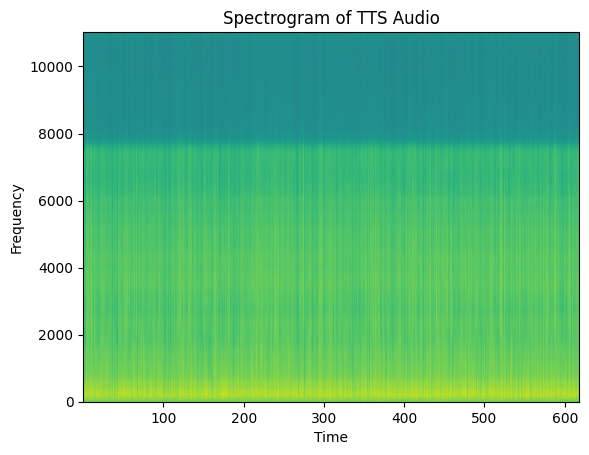

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import wave

# ===== LOAD WAV =====
with wave.open("piper_output.wav", "rb") as f:
    sample_rate = f.getframerate()
    n_frames = f.getnframes()
    audio = np.frombuffer(f.readframes(n_frames), dtype=np.int16)

# ===== NORMALIZE =====
audio = audio.astype(np.float32) / 32768.0

# ===== PLOT SPECTROGRAM =====
plt.figure()
plt.specgram(audio, Fs=sample_rate)
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.title("Spectrogram of TTS Audio")

plt.show()

In [34]:
# import librosa
# import numpy as np
# from fastdtw import fastdtw
# from scipy.spatial.distance import euclidean

# def compute_mdd_score(ref_audio, user_audio, sr=22050):
#     # 1. Trích xuất MFCC
#     ref_mfcc = librosa.feature.mfcc(y=ref_audio.astype(float), sr=sr)
#     user_mfcc = librosa.feature.mfcc(y=user_audio.astype(float), sr=sr)
    
#     # 2. Chạy DTW để tính khoảng cách (distance càng nhỏ phát âm càng giống)
#     distance, path = fastdtw(ref_mfcc.T, user_mfcc.T, dist=euclidean)
    
#     return distance

In [47]:
import sounddevice as sd
from scipy.io.wavfile import write

def record_user_voice(filename="user_voice.wav", duration=2, sr=22050):
    print(f"--- Đang ghi âm trong {duration} giây... (Hãy nói: 你好，很高兴认识你) ---")
    # Ghi âm mono (channels=1)
    recording = sd.rec(int(duration * sr), samplerate=sr, channels=1, dtype='int16')
    sd.wait()
    write(filename, sr, recording)
    print(f"✅ Đã lưu file ghi âm: {filename}")

record_user_voice()

--- Đang ghi âm trong 2 giây... (Hãy nói: 你好，很高兴认识你) ---
✅ Đã lưu file ghi âm: user_voice.wav


In [50]:
import librosa
import numpy as np
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean

def calculate_mdd_score(ref_file, user_file):
    # 1. Load audio và đưa về cùng sample rate
    y_ref, sr_ref = librosa.load(ref_file, sr=22050)
    y_user, sr_user = librosa.load(user_file, sr=22050)

    # 2. Trích xuất MFCC (Đặc trưng âm học)
    mfcc_ref = librosa.feature.mfcc(y=y_ref, sr=sr_ref)
    mfcc_user = librosa.feature.mfcc(y=y_user, sr=sr_user)

    # 3. Chạy DTW để tính khoảng cách giữa 2 ma trận MFCC
    # .T để chuyển vị vì fastdtw nhận (n_samples, n_features)
    distance, path = fastdtw(mfcc_ref.T, mfcc_user.T, dist=euclidean)

    # 4. Chuẩn hóa điểm số theo độ dài đường đi (càng nhỏ càng giống)
    normalized_score = distance / len(path)
    
    print(f"--- Kết quả MDD ---")
    print(f"Distance Score: {normalized_score:.2f} (0 là khớp hoàn toàn)")
    
    if normalized_score < 20:
        print("🎯 Đánh giá: Phát âm rất tốt!")
    elif normalized_score < 40:
        print("👍 Đánh giá: Khá ổn, cần chú ý thanh điệu.")
    else:
        print("⚠️ Đánh giá: Phát âm chưa chuẩn, hãy thử lại.")

# Chạy so sánh giữa file từ Piper và file em vừa ghi âm
calculate_mdd_score("piper_output.wav", "user_voice.wav")

--- Kết quả MDD ---
Distance Score: 244.89 (0 là khớp hoàn toàn)
⚠️ Đánh giá: Phát âm chưa chuẩn, hãy thử lại.


In [17]:
import os, wave, numpy as np
import librosa
from fastdtw import fastdtw
from scipy.spatial.distance import cosine # Đổi sang Cosine
from piper.voice import PiperVoice
from IPython.display import Audio, display

# --- CẤU HÌNH ---
PIPER_BASE = os.path.abspath("../models/piper/")
SPEAKER_CONFIG = {
    "chaowen": "chaowen/zh_CN-chaowen-medium.onnx",
    "huayan": "huayan/zh_CN-huayan-medium.onnx",
    "xiao_ya": "xiao_ya/zh_CN-xiao_ya-medium.onnx"
}

def generate_voice_file(text, speaker_name, output_name):
    model_path = os.path.join(PIPER_BASE, SPEAKER_CONFIG[speaker_name])
    if not os.path.exists(model_path): return False
    
    voice = PiperVoice.load(model_path)
    audio_data = []
    for chunk in voice.synthesize(text):
        if hasattr(chunk, 'audio_int16_array'):
            audio_data.append(chunk.audio_int16_array)
    
    full_audio = np.concatenate(audio_data)
    with wave.open(output_name, "wb") as f:
        f.setnchannels(1)
        f.setsampwidth(2)
        f.setframerate(voice.config.sample_rate)
        f.writeframes(full_audio.tobytes())
    return True

def compare_mdd_v2(file1, file2):
    # 1. Load & Trim
    y1, sr1 = librosa.load(file1, sr=22050)
    y2, sr2 = librosa.load(file2, sr=22050)
    y1, _ = librosa.effects.trim(y1)
    y2, _ = librosa.effects.trim(y2)

    # 2. Trích xuất MFCC
    mfcc1 = librosa.feature.mfcc(y=y1, sr=sr1, n_mfcc=13)
    mfcc2 = librosa.feature.mfcc(y=y2, sr=sr2, n_mfcc=13)

    # --- BƯỚC MỚI: CHUẨN HÓA CMVN ---
    # Giúp loại bỏ sự khác biệt về 'loa' và 'âm sắc riêng'
    mfcc1 = (mfcc1 - np.mean(mfcc1, axis=1, keepdims=True)) / (np.std(mfcc1, axis=1, keepdims=True) + 1e-8)
    mfcc2 = (mfcc2 - np.mean(mfcc2, axis=1, keepdims=True)) / (np.std(mfcc2, axis=1, keepdims=True) + 1e-8)

    # 3. Tính DTW với Cosine Distance
    # Cosine trả về giá trị từ 0 đến 2 (càng gần 0 càng giống)
    distance, path = fastdtw(mfcc1.T, mfcc2.T, dist=cosine)
    
    # 4. Chuẩn hóa điểm số theo độ dài path
    # Thường kết quả sẽ nằm trong khoảng 0.0 -> 1.0
    normalized_score = distance / len(path)
    
    return normalized_score

# --- THỰC THI ---
input_text = "所以你看， 颜色这么简单的东西， 在不同的文化里， 它的意思也是不一样的。"
speaker_a = "huayan"
speaker_b = "chaowen" # Thử đổi sang "chaowen" (Nam) để thấy sự khác biệt

file_a = "voice_a.wav"
file_b = "voice_b.wav"

if generate_voice_file(input_text, speaker_a, file_a) and generate_voice_file(input_text, speaker_b, file_b):
    score = compare_mdd_v2(file_a, file_b)
    
    print("\n" + "="*40)
    print(f"KẾT QUẢ MDD (COSINE + CMVN)")
    print(f"Giọng A: {speaker_a} vs Giọng B: {speaker_b}")
    print(f"Score: {score:.4f} (Càng gần 0 càng chuẩn)")
    print("="*40)
    
    # Ngưỡng (Threshold) mới dựa trên Cosine Distance
    if score < 0.15:
        print("🎯 ĐÁNH GIÁ: Phát âm cực chuẩn (Khớp âm vị).")
    elif score < 0.25:
        print("👍 ĐÁNH GIÁ: Khá chuẩn, có thể chấp nhận được.")
    else:
        print("⚠️ ĐÁNH GIÁ: Sai lệch nhiều, hãy kiểm tra lại.")


KẾT QUẢ MDD (COSINE + CMVN)
Giọng A: huayan vs Giọng B: chaowen
Score: 0.6109 (Càng gần 0 càng chuẩn)
⚠️ ĐÁNH GIÁ: Sai lệch nhiều, hãy kiểm tra lại.
